**Parameters and initialisation of macroscale finite element spaces**

In [ ]:
from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import *
import matplotlib.pyplot as plt


### Macro Meshing ###
k = 1 # Order of elements
Ne = 212 # Number of elements

### Deterministic Meshing ###
Ne_deterministic = 10000

### Micro Meshing ###
Ne_m = 75
lm = 5e-3

### Physical ###
U = 2
eta = 1e-1
rho = 1
h0 = 0.2
dhdx = 0.15

# Microscale roughness
Ah = 10e-3

# Coupling tolerance
p_tol = 1e-6

# Newton solver tolerance (macro and micro)
Newton_tol = 1e-6


**Macroscale Solver**

Solving the smooth, steady, isoviscous, newtonian 1D Lubrication
problem.

We can define the problem as being conservation of flux.

Strong form:

$$
\nabla \cdot \rho q = 0 \\
q = \frac{UH(x)}{2} - \frac{H^3(x)}{12 \eta}\nabla P
$$

- Weak form/Lagrangian
- BCs

In [ ]:
from ngsolve.solvers import *
import numpy as np
from ngsolve.webgui import Draw

def Solve_Macroscale(mesh, hg, dQ, dP):

  # Create a H1, order k space for the pressure field
  V_Macro = H1(mesh, order=k, dirichlet=".*") # All boundaries are set to dirichlet, p = 0. Neumann conditions applied naturally in the weak form.
  p = V_Macro.TrialFunction()  # Pressure trial function
  v = V_Macro.TestFunction()   # Pressure test function
  p_Macro = GridFunction(V_Macro)  # solution
  film_Macro = GridFunction(V_Macro)
  dpdx_Macro = GridFunction(V_Macro)

  a_Macro = BilinearForm(V_Macro)
  h = hg(x, h0, dhdx)
  a_Macro += (h**3 / (12 * eta)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  if dQ is not None:
    dQ_gf = GridFunction(V_Macro)
    dQ_gf.vec.FV().NumPy()[:] = dQ  # load nodal values
    a_Macro += -dQ_gf * grad(v) * dx
  a_Macro.Assemble()

  Newton(
      a_Macro,
      p_Macro,
      freedofs=V_Macro.FreeDofs(),
      maxit=100,
      maxerr=Newton_tol,
      inverse="sparsecholesky",
      printing=False,
  )
  film_Macro.Set(h)
  dpdx = grad(p_Macro)
  dpdx_Macro.Set(dpdx)

  #Construct array of zeta: {H, P, dPdX}
  zeta = np.array([film_Macro.vec.data, p_Macro.vec.data, dpdx_Macro.vec.data])
  return zeta

def q_re(zeta_i):
  """
  Helper function for calculating nodal flux per Reynolds
  """
  H, P, dPdX = zeta_i
  return U * H/2 - H**3 * dPdX / (12 * eta)



**Solve Macroscale Smooth**

In [ ]:
# Film thickness function
def hg(x, h0, dhdx):
  return h0 - dhdx*x

# Create mesh
mesh = Make1DMesh(Ne)

# Solve
zeta = Solve_Macroscale(mesh, hg, 0, 0)
Q_re_smooth = q_re(zeta)
zeta_smooth = zeta

**Deterministic**

In [ ]:
# Create Determinstic mesh
mesh_deterministic = Make1DMesh(Ne_deterministic)

def hg_determinstic(x, h0, dhdx):
  return h0 - dhdx*x + Ah * cos(2 * pi * x/lm)
import time
start = time.time()
zeta_deterministic = Solve_Macroscale(mesh_deterministic, hg_determinstic, 0, 0)
print(f'Exec time {time.time() - start}')

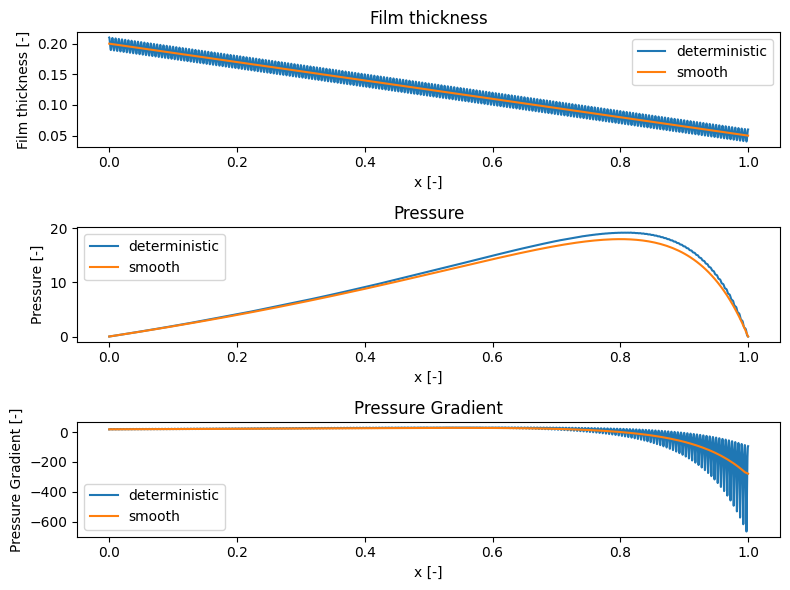

In [ ]:
from plot_funcs import *

plot_zeta_combined(zeta, zeta_deterministic)

**Microscale**

In [ ]:
from netgen.meshing import *

def build_micro_mesh(n, Lx):
  mesh = Mesh(dim=1)
  pids = []
  for i in range(n+1):
      pids.append (mesh.Add (MeshPoint(Pnt(i/n, 0, 0))))
  for i in range(n):
      mesh.Add(Element1D([pids[i],pids[i+1]],index=1))
  mesh.Add (Element0D( pids[0], index=1))
  mesh.Add (Element0D( pids[n], index=2))
  mesh.AddPointIdentification(pids[0],pids[n],1,2)
  mesh.SetBCName(0, "left")
  mesh.SetBCName(1, "right")
  meshout = ngsolve.Mesh(mesh)
  boundaries = meshout.GetBoundaries()
  return meshout


def Solve_microscale(zeta_i, meshm, ref, lx):
  # Unpack zeta
  h0, p0, dpdx0 = zeta_i
  ### Meshing ###
  k = 1 # Order of elements

  # Pressure gain/drop
  dpx = dpdx0 * lx # pressure increase from left to right
  # Reference pressure for point constraint - avoiding negative pressures
  pr = p0 - 0.5*dpx
  pm = pr + (dpx if dpx < 0 else 0.0)
  pconst = pr if pm >= 0.0 else (pr - pm)

  # Film thickness function
  def hg(x, h0):
    return h0 + Ah * cos(2 * pi * x*lx / lx)

  # Create a H1, order k space for the pressure field
  V_micro = Compress(H1(meshm, order=k)) # All boundaries are set to dirichlet, p = 0. Neumann conditions applied naturally in the weak form.
  V_micro.FreeDofs()[0] = False #Set the first boundary DOF as fixed - we set this to a reference value later
  V_micro.FreeDofs()[-1] = False #Set the last boundary DOF as fixed

  p = V_micro.TrialFunction()  # Pressure trial function
  v = V_micro.TestFunction()   # Pressure test function
  sol = GridFunction(V_micro)  # solution
  sol.vec[0] = pconst # Fix corner pressure value
  sol.vec[-1] = pconst + dpx

  a_micro = BilinearForm(V_micro)
  h = hg(x, h0)
  a_micro += (h**3 /  (12 * eta * lx)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  a_micro.Assemble()

  Newton(
      a_micro,
      sol,
      freedofs=V_micro.FreeDofs(),
      maxit=200,
      maxerr=Newton_tol,
      inverse="umfpack",
      printing=False,
  )
  p_micro = GridFunction(V_micro)
  film_micro = GridFunction(V_micro)
  dpdx_micro = GridFunction(V_micro)
  p_micro.Set(sol)
  film_micro.Set(h)
  dpdx_calc = grad(p_micro)/lm
  dpdx_micro.Set(dpdx_calc)

  qx = U * h / 2 - h**3 * dpdx_micro / (12 * eta)

  Pst = Integrate(p_micro, meshm)
  Qst = Integrate(qx, meshm)
  # Qst = U * h0/2 - h0**3 * dpdx0 / (12 * eta)
  pmax = np.max(p_micro.vec.data)
  pmin = np.min(p_micro.vec.data)
  hmax = np.max(film_micro.vec.data)
  hmin = np.min(film_micro.vec.data)

  # if ref ==0:
  #   plt.plot(p_gridfunction.vec.data)
  #   plt.show()
  # if ref == 20:
  #   plt.plot(p_gridfunction.vec.data)
  #   plt.show()
  return Pst, Qst, pmax, pmin, hmax, hmin


def dP_calc(zeta_i, Pst):
  _, P, _ = zeta_i
  return Pst - P

def dQ_calc(zeta_i, Qst):
  Q_re = q_re(zeta_i)
  return Qst - Q_re

**HMM Coupling**

In [ ]:
mesh_m = build_micro_mesh(Ne_m, Lx=lm)
x_vals_m = np.linspace(0, 1, Ne_m)

p_old = zeta[1,:]
p_err = 1
idx = 0
start = time.time()
while p_err > p_tol:
  print(f'Starting iteration {idx}')
  micro_results = []

  # For each set of values in zeta, run a microscale simulation
  for i in range(np.size(zeta[0,:])):
    zeta_i = zeta[:,i]
    Pst, Qst, pmax, pmin, hmax, hmin = Solve_microscale(zeta_i, mesh_m, i, lx = lm)
    micro_results.append([Pst, Qst, pmax, pmin, hmax, hmin])
  micro_results = np.asarray(micro_results)
  print(f'Total Micro calls = {i}')

  dP = dP_calc(zeta, micro_results[:,0])
  dQ = dQ_calc(zeta, micro_results[:,1])
  Q_re = q_re(zeta)

  zeta = Solve_Macroscale(mesh, hg, dQ, dP)

  p_new = zeta[1,:]
  p_err = np.linalg.norm(p_new - p_old)
  print(f'Perr: {p_err:.6f}')
  p_old = p_new
  idx += 1
print(f'HMM Time {time.time() - start}')


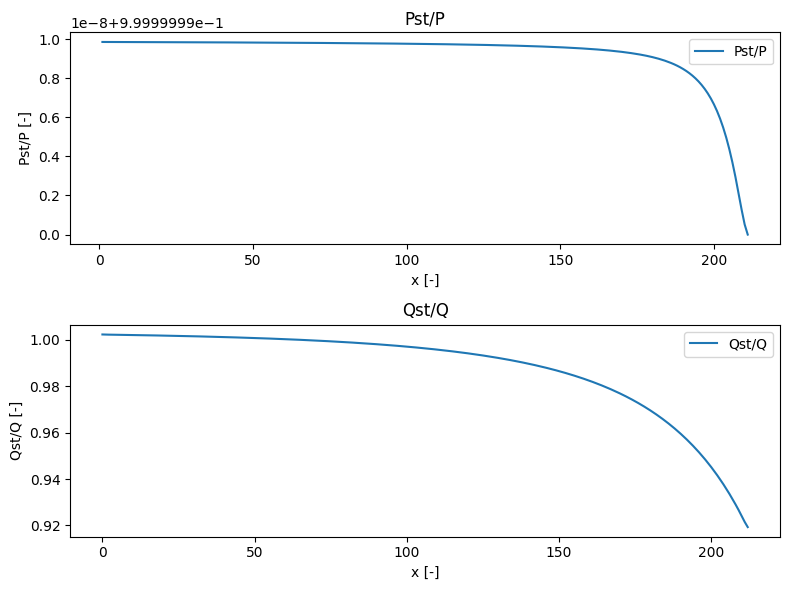

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes[0].plot(micro_results[:,0]/zeta[1,:], label="Pst/P")
axes[0].set_xlabel("x [-]")
axes[0].set_ylabel("Pst/P [-]")
axes[0].set_title("Pst/P")
axes[0].legend()

axes[1].plot(micro_results[:,1]/Q_re, label="Qst/Q")
axes[1].set_xlabel("x [-]")
axes[1].set_ylabel("Qst/Q [-]")
axes[1].set_title("Qst/Q")
axes[1].legend()

plt.tight_layout()
plt.show()


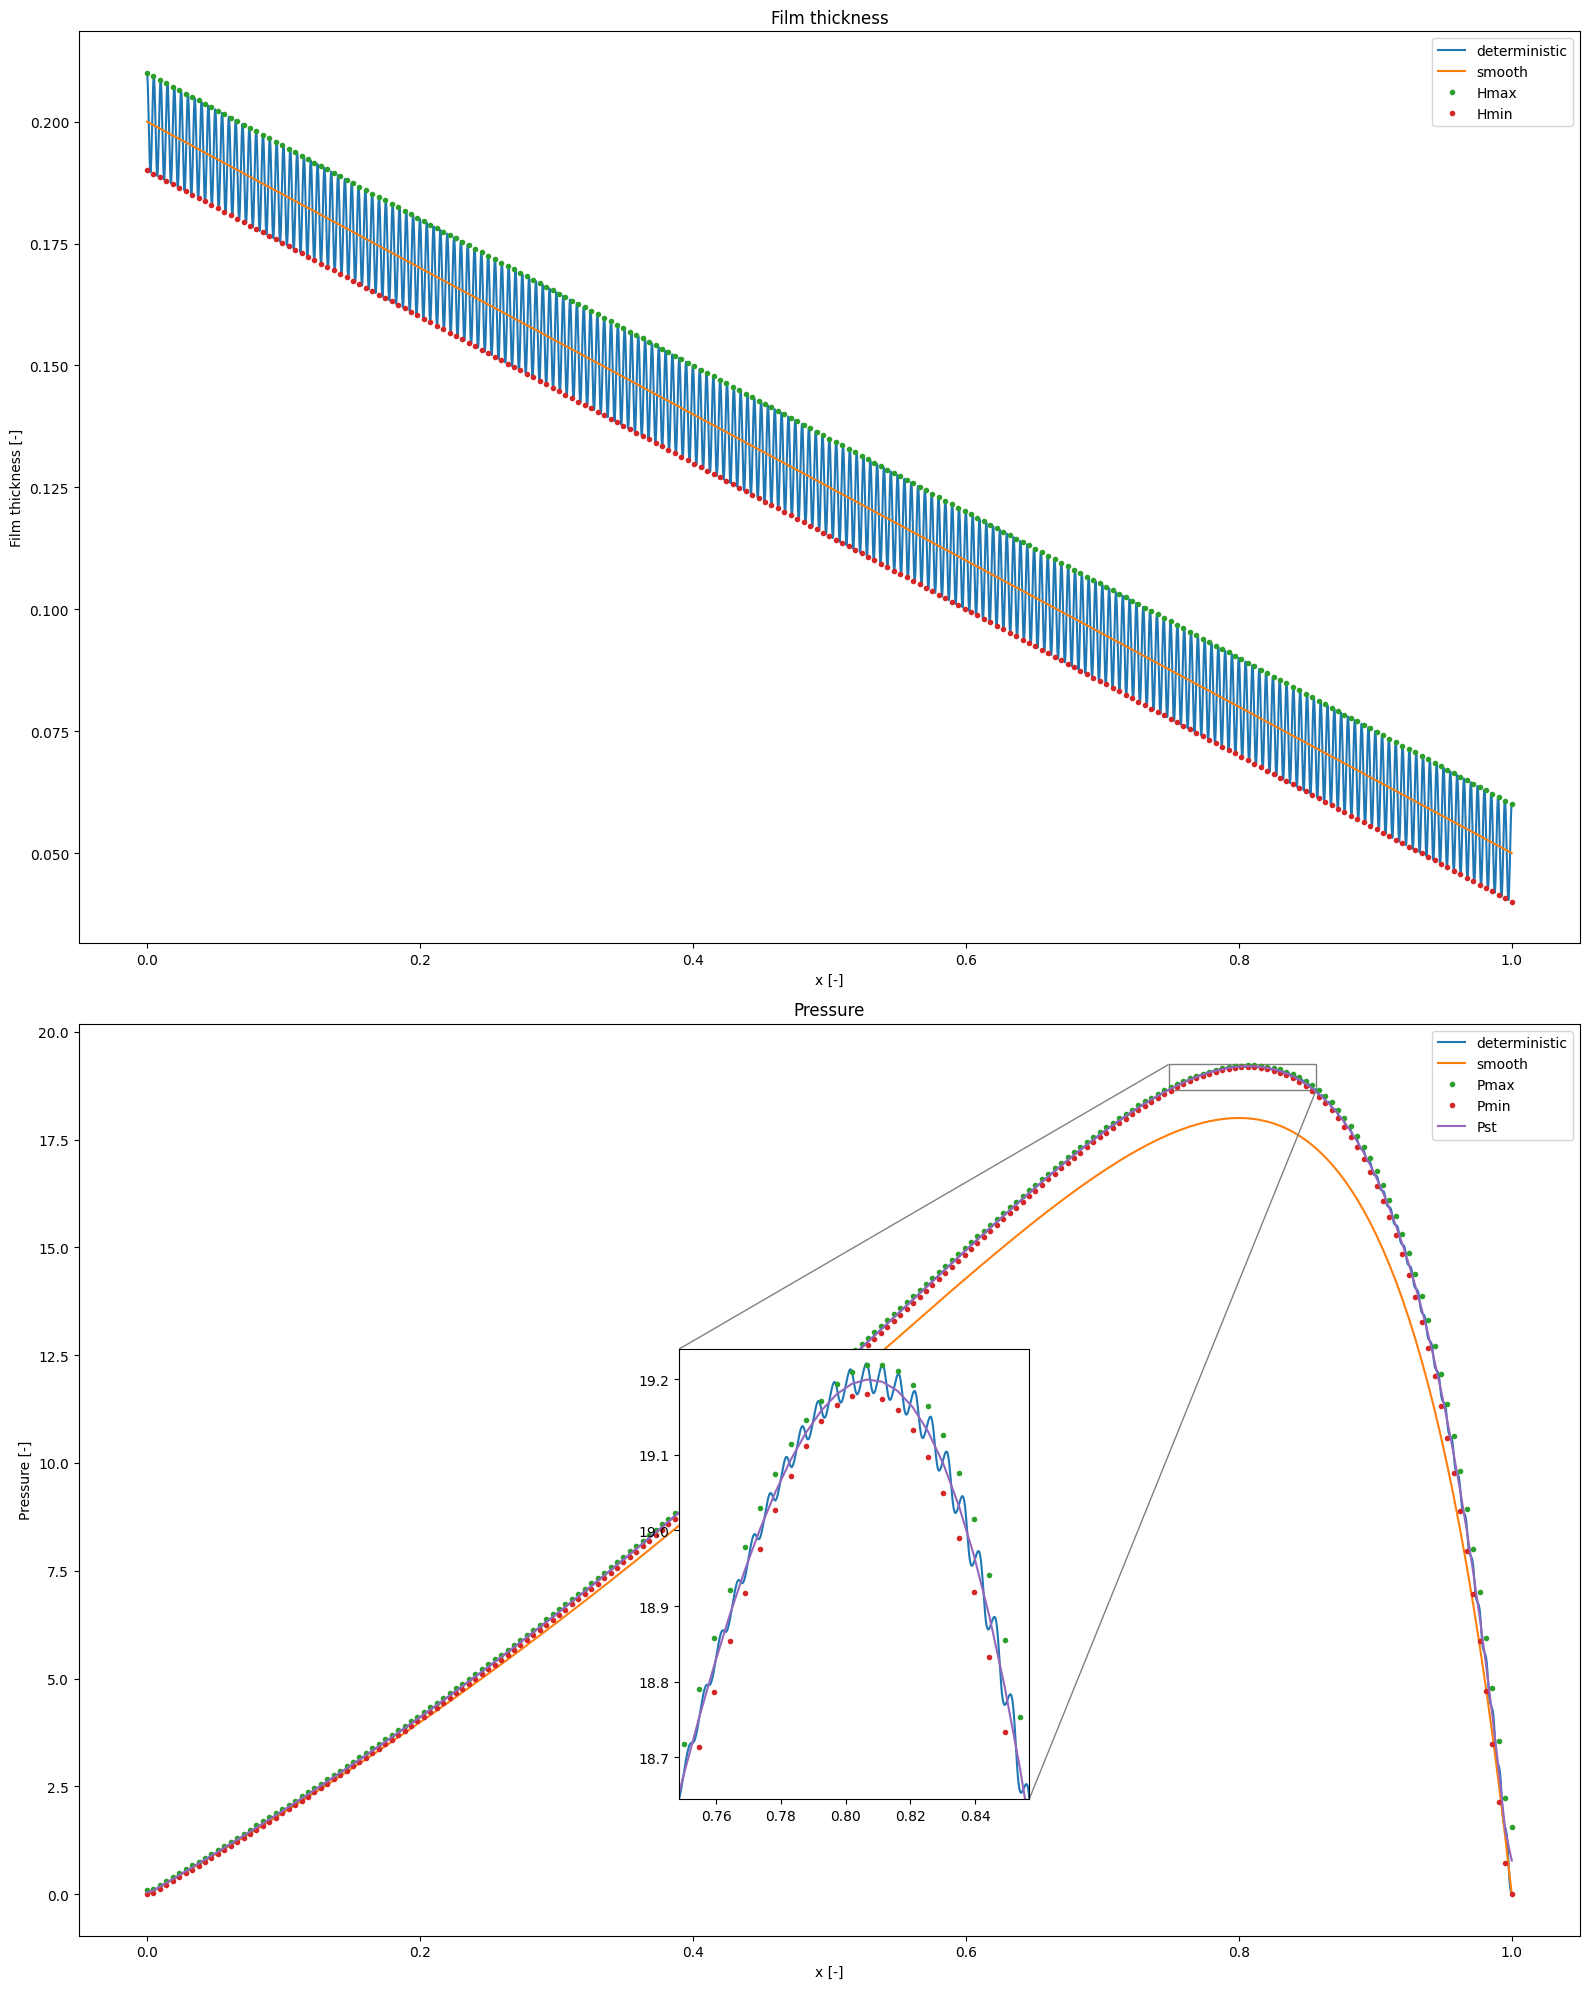

In [ ]:
from plot_funcs import *
plot_zeta_combined2(zeta_smooth, zeta_deterministic, micro_results)